In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import re
import numpy as np
import os
import io
import zipfile
import unicodedata
import geopandas as gpd
from IPython.display import display
from tabulate import tabulate

#A0
# Definir las columnas necesarias
eno_cols = [
    "ENO", "anho_notificacion", "region", "codigo_comuna_residencia",
    "nacionalidad", "sexo", "grupo_edad", "nombre_instruccion",
    "cie_10_diagnostico", "diagnostico", "pais_contagio"
]

# Cargar el dataset con delimitador ";" y codificación UTF-8 con BOM
eno = pd.read_csv(
    "20241218_base_eno_final.csv",
    sep=";", encoding="utf-8-sig", usecols=eno_cols
)

# Verificar carga inicial
print(eno.shape)
print(eno.info())

(333300, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 333300 entries, 0 to 333299
Data columns (total 11 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   region                    333300 non-null  object
 1   nacionalidad              333300 non-null  object
 2   cie_10_diagnostico        333300 non-null  object
 3   diagnostico               333300 non-null  object
 4   anho_notificacion         333300 non-null  int64 
 5   ENO                       333300 non-null  object
 6   nombre_instruccion        333300 non-null  object
 7   pais_contagio             333300 non-null  object
 8   sexo                      333300 non-null  object
 9   grupo_edad                333300 non-null  object
 10  codigo_comuna_residencia  333300 non-null  object
dtypes: int64(1), object(10)
memory usage: 28.0+ MB
None


In [2]:
# Definir tus comunas asignadas
MY_COMUNAS = ["05101", "05102"] #Valparaíso y Casablanca

# Filtrar solo las filas correspondientes a tus comunas
eno_com = eno[eno["codigo_comuna_residencia"].isin(MY_COMUNAS)]
print(f"Rows in my comunas: {len(eno_com):,}")

# Contar cuántas filas están anonimizadas
anon_count = (eno["codigo_comuna_residencia"] == "*****").sum()
print(f"Rows with anonymized comuna (*****): {anon_count:,}")

# Calcular el porcentaje de registros anonimizados
total_rows = len(eno)
anon_pct = anon_count / total_rows * 100
print(f"Anonymized rows percentage: {anon_pct:.2f}%")

Rows in my comunas: 4,547
Rows with anonymized comuna (*****): 148,217
Anonymized rows percentage: 44.47%


In [3]:
# Distribución de nacionalidad en tus comunas filtradas
dist_nac = eno_com["nacionalidad"].value_counts()
print("Distribución de nacionalidad en mis comunas:")
print(dist_nac)

# Contar cuántos registros son 'Desconocido'
desconocidos = (eno_com["nacionalidad"] == "Desconocido").sum()
print(f"Rows with nacionalidad == 'Desconocido': {desconocidos:,}")

# Excluir 'Desconocido' para análisis específicos
eno_com_clean = eno_com[eno_com["nacionalidad"] != "Desconocido"]
print(f"Rows after dropping 'Desconocido': {len(eno_com_clean):,}")

Distribución de nacionalidad en mis comunas:
nacionalidad
Desconocido    2331
Chile          1969
Extranjero      247
Name: count, dtype: int64
Rows with nacionalidad == 'Desconocido': 2,331
Rows after dropping 'Desconocido': 2,216


In [4]:

# Rango de años
min_year = eno_com["anho_notificacion"].min()
max_year = eno_com["anho_notificacion"].max()
print(f"Range of anho_notificacion: {min_year} – {max_year}")

# Conteo de notificaciones por año
notifs_per_year = (
    eno_com["anho_notificacion"]
    .value_counts()
    .sort_index()
    .reset_index()
)

notifs_per_year.columns = ["Año de notificación", "Número de notificaciones"]

# Mostrar tabla con cuadrícula
print("\nTabla de notificaciones por año en mis comunas:")
print(tabulate(notifs_per_year, headers="keys", tablefmt="grid"))

Range of anho_notificacion: 2007 – 2024

Tabla de notificaciones por año en mis comunas:
+----+-----------------------+----------------------------+
|    |   Año de notificación |   Número de notificaciones |
+====+=======================+============================+
|  0 |                  2007 |                        106 |
+----+-----------------------+----------------------------+
|  1 |                  2008 |                        111 |
+----+-----------------------+----------------------------+
|  2 |                  2009 |                        131 |
+----+-----------------------+----------------------------+
|  3 |                  2010 |                         90 |
+----+-----------------------+----------------------------+
|  4 |                  2011 |                        153 |
+----+-----------------------+----------------------------+
|  5 |                  2012 |                        141 |
+----+-----------------------+----------------------------+
|  6 |     

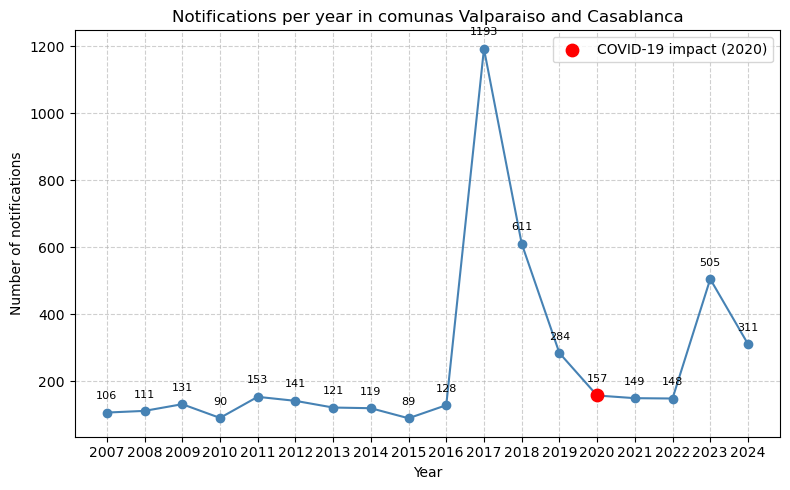

In [5]:

#A1
# Conteo de notificaciones por año en tus comunas
notifs_per_year = (
    eno_com["anho_notificacion"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(8,5))

# Graficar todos los años en azul
plt.plot(notifs_per_year.index, notifs_per_year.values, marker="o", linestyle="-", color="steelblue")

# Destacar el año 2020 en rojo
if 2020 in notifs_per_year.index:
    plt.scatter(2020, notifs_per_year.loc[2020], color="red", s=80, zorder=5, label="COVID-19 impact (2020)")

# Título y etiquetas
plt.title("Notifications per year in comunas Valparaiso and Casablanca")
plt.xlabel("Year")
plt.ylabel("Number of notifications")

# Subir un poco más los valores de los números
for year, count in notifs_per_year.items():
    plt.text(year, count+40, str(count), ha="center", fontsize=8)

# Ajustar eje X para que muestre solo enteros
plt.xticks(notifs_per_year.index)   # fuerza a usar los años exactos como etiquetas

# Añadir leyenda para el punto destacado
plt.legend()

plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

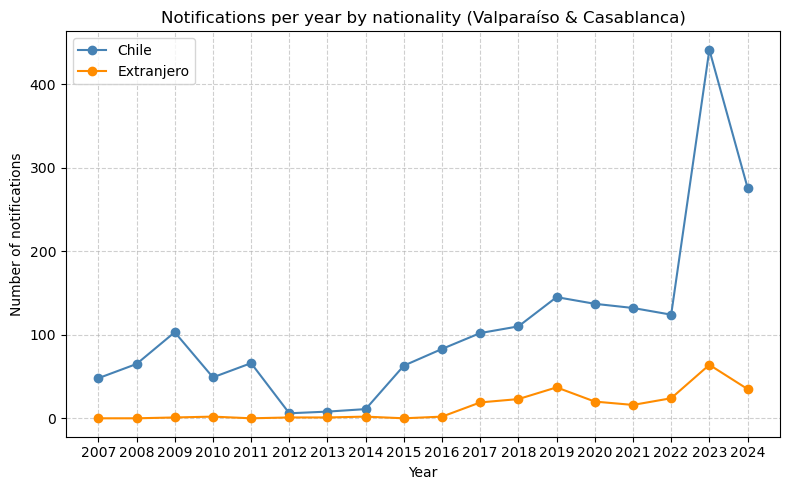

In [6]:
# Excluir 'Desconocido'
eno_com_nat = eno_com[eno_com["nacionalidad"] != "Desconocido"]

# Agrupar por año y nacionalidad
trend_nat = (
    eno_com_nat.groupby(["anho_notificacion", "nacionalidad"])
    .size()
    .reset_index(name="count")
)

# Pivotear para tener columnas Chile / Extranjero
trend_nat_pivot = trend_nat.pivot(index="anho_notificacion", columns="nacionalidad", values="count").fillna(0)

# Graficar
plt.figure(figsize=(8,5))
plt.plot(trend_nat_pivot.index, trend_nat_pivot["Chile"], marker="o", linestyle="-", color="steelblue", label="Chile")
plt.plot(trend_nat_pivot.index, trend_nat_pivot["Extranjero"], marker="o", linestyle="-", color="darkorange", label="Extranjero")

plt.title("Notifications per year by nationality (Valparaíso & Casablanca)")
plt.xlabel("Year")
plt.ylabel("Number of notifications")
plt.xticks(trend_nat_pivot.index)  # mostrar años como enteros
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show(17)  #Dejo la tabla para que se pueda ver de forma mas clara los numeeros que se grafican

In [7]:
#Cambio la proporcion con los años? Veamos como se ha comportado esta proporcion a lo largo de los años
# Calcular el porcentaje de extranjeros por año
trend_nat_pivot["share_extranjero"] = trend_nat_pivot["Extranjero"] / (trend_nat_pivot["Chile"] + trend_nat_pivot["Extranjero"]) * 100

print("Porcentaje de notificaciones de extranjeros por año:")
print(trend_nat_pivot[["share_extranjero"]])

Porcentaje de notificaciones de extranjeros por año:
nacionalidad       share_extranjero
anho_notificacion                  
2007                       0.000000
2008                       0.000000
2009                       0.961538
2010                       3.921569
2011                       0.000000
2012                      14.285714
2013                      11.111111
2014                      15.384615
2015                       0.000000
2016                       2.352941
2017                      15.702479
2018                      17.293233
2019                      20.329670
2020                      12.738854
2021                      10.810811
2022                      16.216216
2023                      12.673267
2024                      11.254019


Como se puede ver, con el tiempo ha ido aumentando la porcentaje de notificaciones de enfermedades a extranjeros, esto probablemente sea dado el numero de migrantes que ha aumentado durante los años teniendo su auge en 2019, luego disminuyo casi 8% donde el principal culpable fue el COVID-19, de ahi se ha mantenido relativamente estable entre un 10-16% aprox.

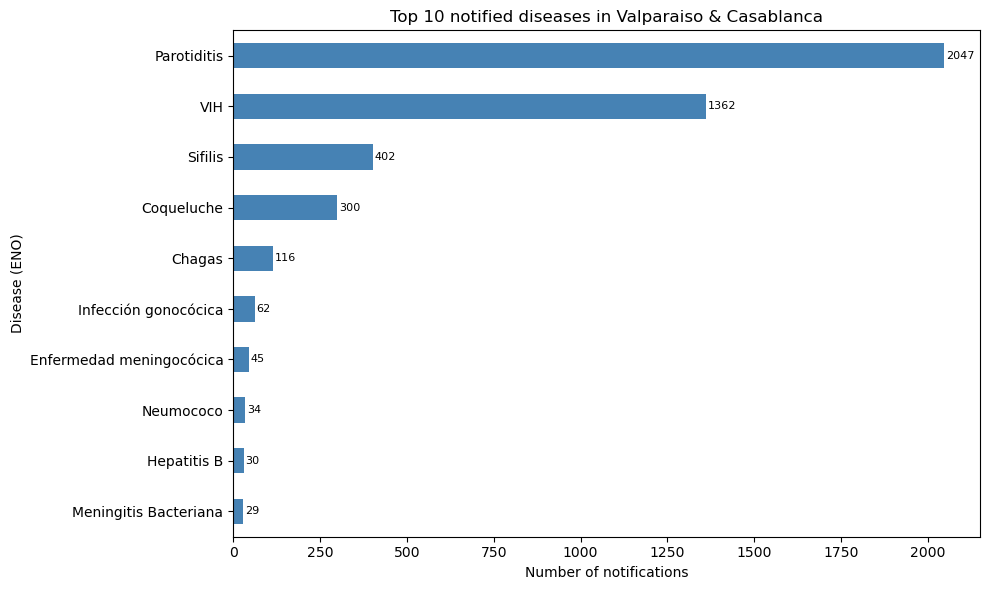

In [8]:
#A2.1

# Contar las 10 enfermedades más notificadas en todas las comunas filtradas
top_diseases = eno_com["ENO"].value_counts().nlargest(10)

# Crear gráfico de barras horizontales
plt.figure(figsize=(10,6))
top_diseases.plot(kind="barh", color="steelblue")

#Invertir el orden para que la enfermedad más notificada esté arriba
plt.gca().invert_yaxis()


# Título y etiquetas
plt.title("Top 10 notified diseases in Valparaiso & Casablanca")
plt.xlabel("Number of notifications")
plt.ylabel("Disease (ENO)")

# Mostrar valores al lado de cada barra
for i, v in enumerate(top_diseases.values):
    plt.text(v + 5, i, str(v), va="center", fontsize=8)

plt.tight_layout()
plt.show()


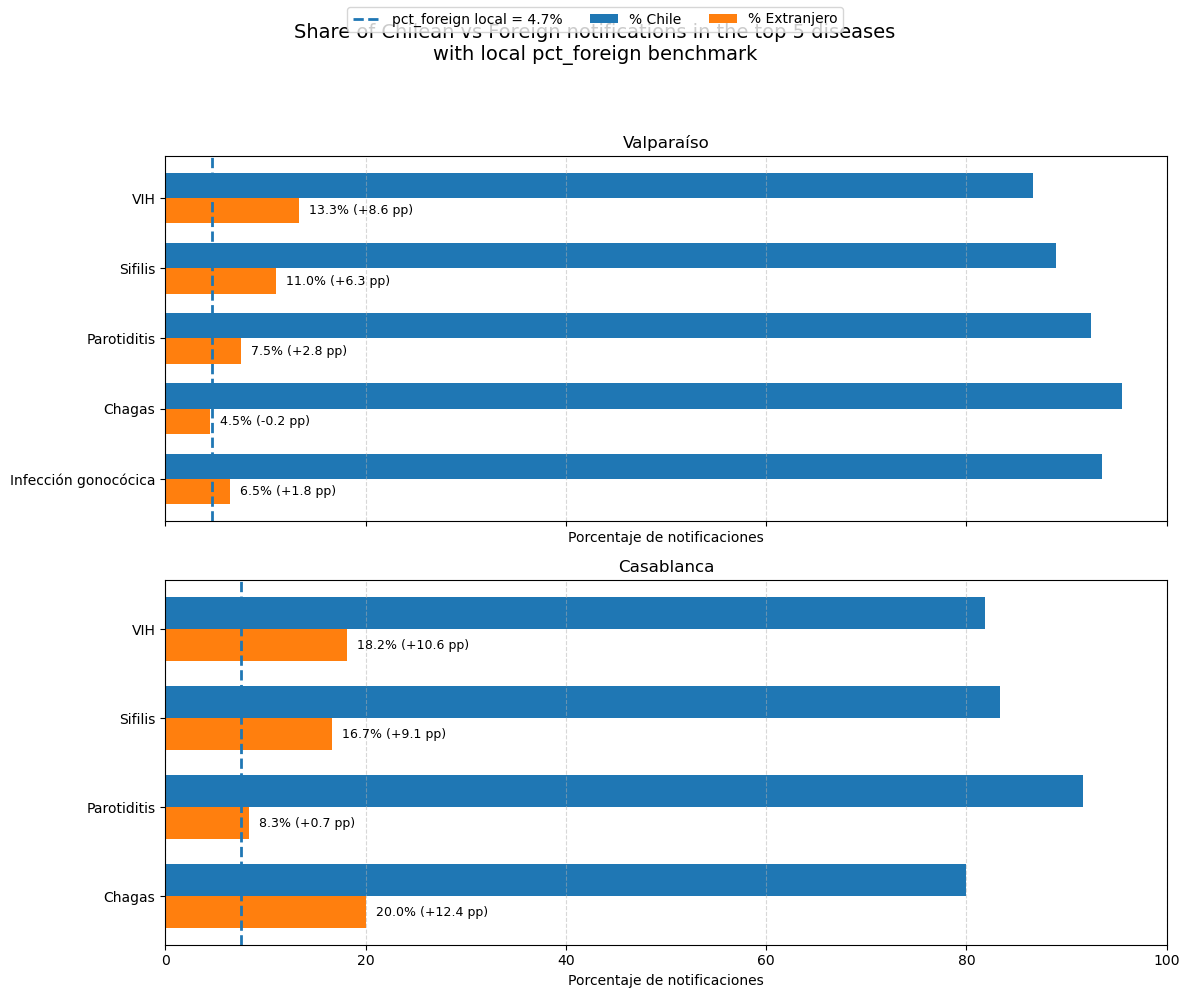

+------------+----------------------+---------+--------------+-----------+----------------+---------------------+----------+--------------------+
| comuna     | ENO                  |   Chile |   Extranjero |   % Chile |   % Extranjero |   pct_foreign_local |   dif_pp | estado             |
+============+======================+=========+==============+===========+================+=====================+==========+====================+
| Casablanca | Chagas               |       4 |            1 |      80   |           20   |                 7.6 |     12.4 | Sobre-representada |
+------------+----------------------+---------+--------------+-----------+----------------+---------------------+----------+--------------------+
| Casablanca | Parotiditis          |      11 |            1 |      91.7 |            8.3 |                 7.6 |      0.7 | Sobre-representada |
+------------+----------------------+---------+--------------+-----------+----------------+---------------------+----------+

In [9]:
#A.2.2
# Excluir nacionalidad desconocida
eno_com_clean = eno_com[eno_com["nacionalidad"] != "Desconocido"].copy()

# Asegurar formato texto en código de comuna
eno_com_clean["codigo_comuna_residencia"] = eno_com_clean["codigo_comuna_residencia"].astype(str)

# Mapas de comuna y benchmark local de extranjeros
comuna_map = {
    "05101": "Valparaíso",
    "05102": "Casablanca"
}

pct_foreign_map = {
    "05101": 4.7,   # Valparaíso
    "05102": 7.6    # Casablanca
}

eno_com_clean["comuna"] = eno_com_clean["codigo_comuna_residencia"].map(comuna_map)

# Top 5 enfermedades en el total de las comunas
top5_diseases = (
    eno_com_clean["ENO"]
    .value_counts()
    .head(5)
    .index
    .tolist()
)

# Conteos por comuna, enfermedad y nacionalidad
summary = (
    eno_com_clean[eno_com_clean["ENO"].isin(top5_diseases)]
    .groupby(["codigo_comuna_residencia", "comuna", "ENO", "nacionalidad"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

# Asegurar columnas
for col in ["Chile", "Extranjero"]:
    if col not in summary.columns:
        summary[col] = 0

# Porcentajes
summary["total"] = summary["Chile"] + summary["Extranjero"]
summary = summary[summary["total"] > 0].copy()

summary["% Chile"] = 100 * summary["Chile"] / summary["total"]
summary["% Extranjero"] = 100 * summary["Extranjero"] / summary["total"]
summary["pct_foreign_local"] = summary["codigo_comuna_residencia"].map(pct_foreign_map)
summary["dif_pp"] = summary["% Extranjero"] - summary["pct_foreign_local"]

summary["estado"] = np.where(
    summary["dif_pp"] > 0,
    "Sobre-representada",
    np.where(summary["dif_pp"] < 0, "Sub-representada", "Igual al benchmark")
)

# Orden fijo de enfermedades
summary["ENO"] = pd.Categorical(
    summary["ENO"],
    categories=top5_diseases[::-1],   # invertido para que la más frecuente quede arriba
    ordered=True
)

summary = summary.sort_values(["comuna", "ENO"])

# Graficar una figura por comuna
fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

bar_h = 0.36
comunas_plot = ["05101", "05102"]

for ax, cod in zip(axes, comunas_plot):
    dfc = summary[summary["codigo_comuna_residencia"] == cod].sort_values("ENO").copy()
    y = np.arange(len(dfc))
    pct_ref = pct_foreign_map[cod]

    # Barras horizontales
    ax.barh(y + bar_h/2, dfc["% Chile"], height=bar_h, label="% Chile")
    ax.barh(y - bar_h/2, dfc["% Extranjero"], height=bar_h, label="% Extranjero")

    # Línea benchmark local
    ax.axvline(
        pct_ref,
        linestyle="--",
        linewidth=2,
        label=f"pct_foreign local = {pct_ref}%"
    )

    # Etiquetas de las barras de extranjeros con diferencia en puntos porcentuales
    for i, (_, row) in enumerate(dfc.iterrows()):
        signo = "+" if row["dif_pp"] >= 0 else ""
        ax.text(
            row["% Extranjero"] + 1,
            y[i] - bar_h/2,
            f'{row["% Extranjero"]:.1f}% ({signo}{row["dif_pp"]:.1f} pp)',
            va="center",
            fontsize=9
        )

    ax.set_yticks(y)
    ax.set_yticklabels(dfc["ENO"])
    ax.set_xlim(0, 100)
    ax.set_title(f'{comuna_map[cod]}')
    ax.set_xlabel("Porcentaje de notificaciones")
    ax.grid(axis="x", linestyle="--", alpha=0.5)

# Leyenda una sola vez
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles[:3], labels[:3], loc="upper center", ncol=3)

fig.suptitle(
    "Share of Chilean vs Foreign notifications in the top 5 diseases\nwith local pct_foreign benchmark",
    y=0.98,
    fontsize=14
)

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

# Tabla resumen
tabla_final = summary[
    ["comuna", "ENO", "Chile", "Extranjero", "% Chile", "% Extranjero",
     "pct_foreign_local", "dif_pp", "estado"]
].copy()

print(tabulate(tabla_final.round(1), headers="keys", tablefmt="grid", showindex=False))

El gráfico muestra la proporción de notificaciones de personas extranjeras para las principales enfermedades en cada comuna, comparándola con el porcentaje de población extranjera local. Cuando la barra de % Extranjero supera la línea de referencia, se interpreta como una sobrerrepresentación relativa.

En Valparaíso (4.7%), se observa sobrerrepresentación en VIH, sífilis, parotiditis e infección gonocócica, mientras que Chagas se mantiene prácticamente en línea con el valor esperado.

En Casablanca (7.6%), VIH, sífilis, parotiditis y especialmente Chagas presentan sobrerrepresentación respecto a la composición demográfica local.

En términos generales, VIH y sífilis muestran una sobrerrepresentación consistente de notificaciones en población extranjera en ambas comunas.

Top disease in my comunas: Parotiditis

Tabla resumen:
+--------------+---------+--------------+-----------+----------------+
| grupo_edad   |   Chile |   Extranjero |   % Chile |   % Extranjero |
+==============+=========+==============+===========+================+
| 00-04        |      20 |            2 |       7.4 |            9.1 |
+--------------+---------+--------------+-----------+----------------+
| 05-09        |      43 |            2 |      16   |            9.1 |
+--------------+---------+--------------+-----------+----------------+
| 10-14        |      35 |            2 |      13   |            9.1 |
+--------------+---------+--------------+-----------+----------------+
| 15-19        |      18 |            0 |       6.7 |            0   |
+--------------+---------+--------------+-----------+----------------+
| 20-24        |      18 |            6 |       6.7 |           27.3 |
+--------------+---------+--------------+-----------+----------------+
| 25-29        |      

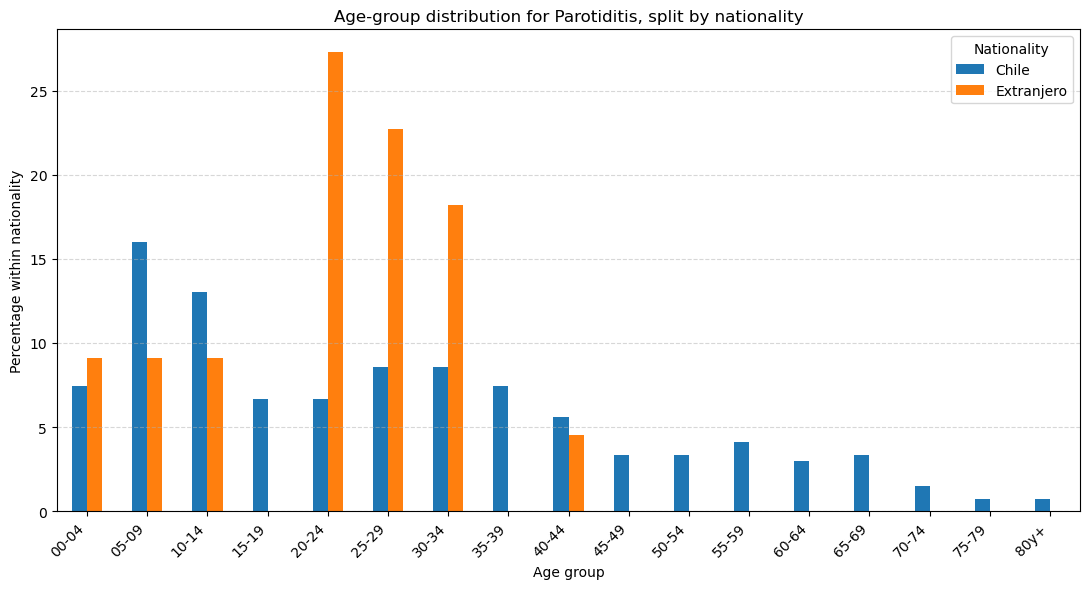

In [10]:
# A.2.3 Age-group distribution for the top disease



# Base limpia para comparar nacionalidad
df = eno_com[
    (eno_com["nacionalidad"] != "Desconocido") &
    (eno_com["grupo_edad"].notna())
].copy()

# Enfermedad más frecuente en tus comunas
top_disease = eno_com["ENO"].value_counts().idxmax()
print(f"Top disease in my comunas: {top_disease}")

# Filtrar solo esa enfermedad
df_top = df[df["ENO"] == top_disease].copy()

# Conteos por grupo de edad y nacionalidad
age_nat_counts = (
    df_top.groupby(["grupo_edad", "nacionalidad"])
    .size()
    .unstack(fill_value=0)
)

# Asegurar columnas
for col in ["Chile", "Extranjero"]:
    if col not in age_nat_counts.columns:
        age_nat_counts[col] = 0

age_nat_counts = age_nat_counts[["Chile", "Extranjero"]]

# Ordenar grupos de edad de manera más natural
def age_sort_key(label):
    s = str(label).lower().strip()
    if "menor" in s:
        return -1
    nums = re.findall(r"\d+", s)
    if nums:
        return int(nums[0])
    return 999

ordered_groups = sorted(age_nat_counts.index, key=age_sort_key)
age_nat_counts = age_nat_counts.loc[ordered_groups]

# Convertir a distribución porcentual dentro de cada nacionalidad
age_nat_pct = age_nat_counts.div(age_nat_counts.sum(axis=0), axis=1) * 100

# Tabla resumen
summary_age = age_nat_counts.copy()
summary_age["% Chile"] = age_nat_pct["Chile"]
summary_age["% Extranjero"] = age_nat_pct["Extranjero"]

print("\nTabla resumen:")
print(tabulate(summary_age.round(1).reset_index(), headers="keys", tablefmt="grid", showindex=False))

# Gráfico: distribución etaria por nacionalidad
ax = age_nat_pct.plot(kind="bar", figsize=(11,6))

plt.title(f"Age-group distribution for {top_disease}, split by nationality")
plt.xlabel("Age group")
plt.ylabel("Percentage within nationality")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Nationality")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

Para parotiditis, la distribución por edad difiere según nacionalidad. En la población chilena, las notificaciones se distribuyen de manera más amplia, con mayor presencia en grupos infantiles y una dispersión que se extiende hacia edades adultas y mayores. En cambio, en la población extranjera los casos se concentran principalmente en adultos jóvenes, especialmente entre 20–24, 25–29 y 30–34 años.

En términos generales, esto sugiere que la parotiditis presenta un perfil etario más joven y concentrado entre personas extranjeras, mientras que en personas chilenas la distribución es más heterogénea y abarca un rango de edades más amplio.

Tabla de notificaciones por comuna:
+------------+-----------------+
| comuna     |   notifications |
+============+=================+
| Valparaíso |            4397 |
+------------+-----------------+
| Casablanca |             150 |
+------------+-----------------+


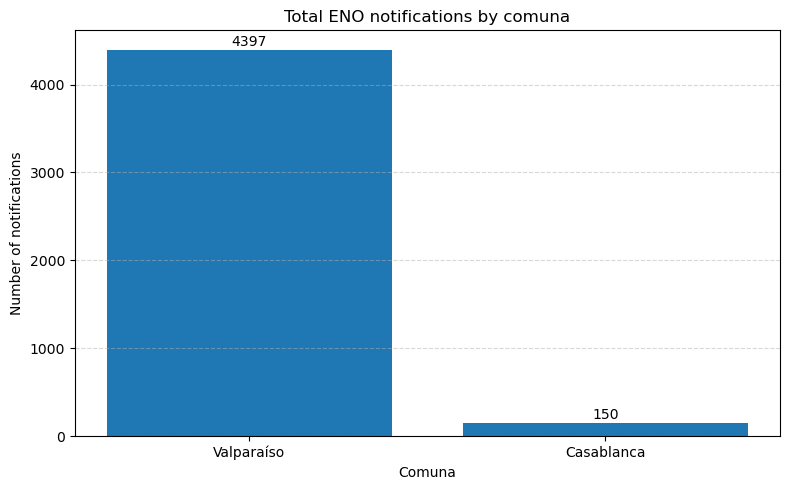

In [11]:
#A.3
# A.3.1 Notification counts by comuna

import pandas as pd
import matplotlib.pyplot as plt
from tabulate import tabulate

# Trabajar sobre una copia
df = eno_com.copy()
df["codigo_comuna_residencia"] = df["codigo_comuna_residencia"].astype(str)

comuna_map = {
    "05101": "Valparaíso",
    "05102": "Casablanca"
}

notif_comuna = (
    df["codigo_comuna_residencia"]
    .value_counts()
    .rename_axis("codigo_comuna_residencia")
    .reset_index(name="notifications")
)

notif_comuna["comuna"] = notif_comuna["codigo_comuna_residencia"].map(comuna_map)

notif_comuna["comuna"] = pd.Categorical(
    notif_comuna["comuna"],
    categories=["Valparaíso", "Casablanca"],
    ordered=True
)

notif_comuna = notif_comuna.sort_values("comuna")

print("Tabla de notificaciones por comuna:")
print(tabulate(notif_comuna[["comuna", "notifications"]], headers="keys", tablefmt="grid", showindex=False))

plt.figure(figsize=(8,5))
plt.bar(notif_comuna["comuna"], notif_comuna["notifications"])

plt.title("Total ENO notifications by comuna")
plt.xlabel("Comuna")
plt.ylabel("Number of notifications")

for i, v in enumerate(notif_comuna["notifications"]):
    plt.text(i, v + max(notif_comuna["notifications"])*0.01, str(v), ha="center")

plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


Tabla con tasa bruta por 10.000 habitantes:
+------------+-----------------+--------------+------------------+
| comuna     |   notifications |   population |   rate_per_10000 |
+============+=================+==============+==================+
| Valparaíso |            4397 |       284938 |           154.31 |
+------------+-----------------+--------------+------------------+
| Casablanca |             150 |        29876 |            50.21 |
+------------+-----------------+--------------+------------------+


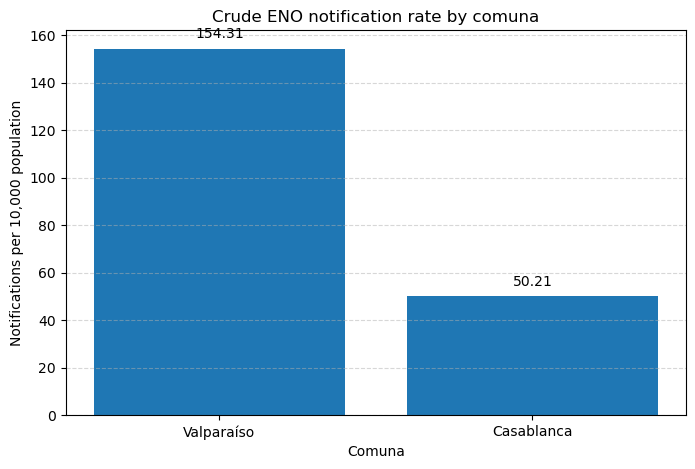

In [12]:
# Poblaciones de Tarea 1
population_map = {
    "05101": 284938,   # Población de Valparaíso
    "05102": 29876    # Población de Casablanca
}

notif_comuna["population"] = notif_comuna["codigo_comuna_residencia"].map(population_map)

if (notif_comuna["population"] > 0).all():
    notif_comuna["rate_per_10000"] = (
        notif_comuna["notifications"] / notif_comuna["population"] * 10000
    )

    print("\nTabla con tasa bruta por 10.000 habitantes:")
    print(tabulate(
        notif_comuna[["comuna", "notifications", "population", "rate_per_10000"]].round(2),
        headers="keys",
        tablefmt="grid",
        showindex=False
    ))

    fig, ax = plt.subplots(figsize=(8, 5), dpi=100)
    bars = ax.bar(notif_comuna["comuna"], notif_comuna["rate_per_10000"])

    ax.set_title("Crude ENO notification rate by comuna")
    ax.set_xlabel("Comuna")
    ax.set_ylabel("Notifications per 10,000 population")
    ax.grid(axis="y", linestyle="--", alpha=0.5)

    offset = notif_comuna["rate_per_10000"].max() * 0.02
    for bar in bars:
        h = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2,
            h + offset,
            f"{h:.2f}",
            ha="center",
            va="bottom"
        )

    plt.show()
else:
    print("\nFaltan las poblaciones en population_map para calcular la tasa.")

In [13]:
# A.4 Comuna-Level ENO Summary Table
# -----------------------------
# 1) Tabla base de Tarea 1
# -----------------------------
# Reemplaza pop_total por los valores reales de Tarea 1
comuna_info = pd.DataFrame({
    "codigo_comuna": ["05101", "05102"],
    "nombre_comuna": ["Valparaíso", "Casablanca"],
    "pop_total": [284938 , 29876 ]   
})

# -----------------------------
# 2) Base ENO limpia
# -----------------------------
df = eno_com.copy()
df["codigo_comuna_residencia"] = (
    df["codigo_comuna_residencia"]
    .astype(str)
    .str.strip()
    .str.zfill(5)
)

# -----------------------------
# 3) Función build_eno_summary
# -----------------------------
def build_eno_summary(g):
    nac_counts = g["nacionalidad"].value_counts()
    top3 = g["ENO"].value_counts().head(3).index.tolist()

    return pd.Series({
        "eno_total": len(g),
        "eno_chilean": int(nac_counts.get("Chile", 0)),
        "eno_foreign": int(nac_counts.get("Extranjero", 0)),
        "eno_desconocido": int(nac_counts.get("Desconocido", 0)),
        "eno_top3_diseases": ", ".join(top3)
    })

# -----------------------------
# 4) Construir tabla resumen ENO
# -----------------------------
eno_summary = (
    df.groupby("codigo_comuna_residencia")
      .apply(build_eno_summary)
      .reset_index()
      .rename(columns={"codigo_comuna_residencia": "codigo_comuna"})
)

eno_summary["codigo_comuna"] = eno_summary["codigo_comuna"].astype(str).str.zfill(5)

# -----------------------------
# 5) Unir con datos de Tarea 1
# -----------------------------
eno_summary = comuna_info.merge(eno_summary, on="codigo_comuna", how="left")

for col in ["eno_total", "eno_chilean", "eno_foreign", "eno_desconocido"]:
    eno_summary[col] = eno_summary[col].fillna(0).astype(int)

eno_summary["eno_top3_diseases"] = eno_summary["eno_top3_diseases"].fillna("")

# -----------------------------
# 6) Calcular tasa por 10.000
# -----------------------------
eno_summary["eno_rate_per_10k"] = (
    eno_summary["eno_total"] / eno_summary["pop_total"] * 10000
)

# -----------------------------
# 7) Orden final de columnas
# -----------------------------
eno_summary = eno_summary[
    [
        "codigo_comuna",
        "nombre_comuna",
        "eno_total",
        "eno_chilean",
        "eno_foreign",
        "eno_desconocido",
        "eno_top3_diseases",
        "eno_rate_per_10k"
    ]
].sort_values("codigo_comuna")

# -----------------------------
# 8) Mostrar en notebook
# -----------------------------
display(eno_summary)

# -----------------------------
# 9) Guardar CSV
# -----------------------------
os.makedirs("output", exist_ok=True)
eno_summary.to_csv("output/tarea2_eno_summary.csv", index=False, encoding="utf-8-sig")

print("Archivo guardado en: output/tarea2_eno_summary.csv")

,codigo_comuna,nombre_comuna,eno_total,eno_chilean,eno_foreign,eno_desconocido,eno_top3_diseases,eno_rate_per_10k
0,05101,Valparaíso,4397,1912,236,2249,"Parotiditis, VIH, Sifilis",154.314272
1,05102,Casablanca,150,57,11,82,"Parotiditis, VIH, Coqueluche",50.207524


Archivo guardado en: output/tarea2_eno_summary.csv


# Part B

In [14]:
grd_cols = [
    "COMUNA", "NACIONALIDAD", "SEXO", "FECHA_NACIMIENTO",
    "FECHA_INGRESO", "FECHAALTA", "TIPOALTA",
    "DIAGNOSTICO1", "DIAGNOSTICO2",
    "IR_29301_SEVERIDAD", "IR_29301_MORTALIDAD",
    "IR_29301_COD_GRD", "TIPO_INGRESO",
    "ESPECIALIDAD_MEDICA"
]

def detect_encoding(zf, txtname):
    with zf.open(txtname) as f:
        prefix = f.read(4)
    if prefix.startswith(b"\xff\xfe") or prefix.startswith(b"\xfe\xff"):
        return "utf-16"
    if prefix.startswith(b"\xef\xbb\xbf"):
        return "utf-8-sig"
    return "latin-1"

frames = []

for year in [2022, 2023, 2024]:
    zippath = f"grd/GRD_PUBLICO_{year}.zip"
    
    with zipfile.ZipFile(zippath) as z:
        txt_files = [name for name in z.namelist() if name.lower().endswith(".txt")]
        print(f"{year}: {txt_files}")
        
        if not txt_files:
            raise FileNotFoundError(f"No encontré un .txt dentro de {zippath}")
        
        txtname = txt_files[0]
        enc = detect_encoding(z, txtname)
        print(f"Leyendo {txtname} con encoding {enc}")
        
        with z.open(txtname) as f:
            text_stream = io.TextIOWrapper(f, encoding=enc, errors="replace")
            df_year = pd.read_csv(
                text_stream,
                sep="|",
                usecols=lambda c: c.strip().upper() in grd_cols,
                engine="python",
                on_bad_lines="skip",
                dtype=str
            )
    
    df_year.columns = df_year.columns.str.strip().str.upper()
    df_year["year"] = year
    frames.append(df_year)

grd = pd.concat(frames, ignore_index=True)

print(f"Total discharges (3 years): {len(grd):,}")
display(grd.head())
print(grd.columns.tolist())

2022: ['GRD_PUBLICO_EXTERNO_2022.txt']
Leyendo GRD_PUBLICO_EXTERNO_2022.txt con encoding utf-16
2023: ['GRD_PUBLICO_2023.txt']
Leyendo GRD_PUBLICO_2023.txt con encoding utf-16
2024: ['GRD_PUBLICO_2024.txt']
Leyendo GRD_PUBLICO_2024.txt con encoding latin-1
Total discharges (3 years): 3,058,240


,SEXO,FECHA_NACIMIENTO,COMUNA,NACIONALIDAD,TIPO_INGRESO,ESPECIALIDAD_MEDICA,FECHA_INGRESO,FECHAALTA,TIPOALTA,DIAGNOSTICO1,DIAGNOSTICO2,IR_29301_COD_GRD,IR_29301_SEVERIDAD,IR_29301_MORTALIDAD,year
0,HOMBRE,2022-01-02,SAN FERNANDO,CHILE,URGENCIA,PEDIATRÍA,2022-08-01,2022-08-09,DOMICILIO,Q03.9,H55,011113,3,1,2022
1,MUJER,1981-07-05,COPIAPO,CHILE,PROGRAMADA,CARDIOLOGÍA,2022-11-01,2022-11-04,DOMICILIO,I47.1,I10,051401,1,1,2022
2,MUJER,1941-06-30,MELIPILLA,CHILE,URGENCIA,MEDICINA INTENSIVA ADULTO,2022-06-30,2022-07-06,FALLECIDO,S72.00,W19.09,084103,3,3,2022
3,MUJER,1997-01-26,MELIPILLA,CHILE,OBSTETRICA,OBSTETRICIA Y GINECOLOGÍA,2022-07-04,2022-07-07,DOMICILIO,O80.0,Z37.0,146131,1,1,2022
4,MUJER,1950-06-03,MELIPILLA,CHILE,URGENCIA,MEDICINA INTENSIVA ADULTO,2022-06-01,2022-07-04,DOMICILIO,J40,B96.2,044213,3,2,2022


['SEXO', 'FECHA_NACIMIENTO', 'COMUNA', 'NACIONALIDAD', 'TIPO_INGRESO', 'ESPECIALIDAD_MEDICA', 'FECHA_INGRESO', 'FECHAALTA', 'TIPOALTA', 'DIAGNOSTICO1', 'DIAGNOSTICO2', 'IR_29301_COD_GRD', 'IR_29301_SEVERIDAD', 'IR_29301_MORTALIDAD', 'year']


In [15]:
# B.0.2 Filter to my comunas
def normalize_text(x):
    if pd.isna(x):
        return pd.NA
    x = str(x).strip().upper()
    x = unicodedata.normalize("NFKD", x)
    x = "".join(c for c in x if not unicodedata.combining(c))  # quitar tildes
    x = " ".join(x.split())  # limpiar espacios dobles
    return x

# Copia limpia
grd = grd.copy()

# Normalizar nombres de comuna en GRD
grd["COMUNA_NORM"] = grd["COMUNA"].apply(normalize_text)

# Las comunas
my_comuna_names = ["VALPARAISO", "CASABLANCA"]

# Filtrar
grd_com = grd[grd["COMUNA_NORM"].isin(my_comuna_names)].copy()

print(f"Discharges in my comunas: {len(grd_com):,}")

# Reportar número de egresos por año
discharges_per_year = (
    grd_com.groupby("year")
    .size()
    .reset_index(name="discharges")
    .sort_values("year")
)

print("\nDischarges per year in my comunas:")
display(discharges_per_year)

# Tabla por comuna y año
discharges_comuna_year = (
    grd_com.groupby(["year", "COMUNA_NORM"])
    .size()
    .reset_index(name="discharges")
    .sort_values(["year", "COMUNA_NORM"])
)

print("\nDischarges per year and comuna:")
display(discharges_comuna_year)

Discharges in my comunas: 63,186

Discharges per year in my comunas:


,year,discharges
0,2022,18644
1,2023,22030
2,2024,22512



Discharges per year and comuna:


,year,COMUNA_NORM,discharges
0,2022,CASABLANCA,1345
1,2022,VALPARAISO,17299
2,2023,CASABLANCA,1606
3,2023,VALPARAISO,20424
4,2024,CASABLANCA,1756
5,2024,VALPARAISO,20756


In [16]:
# B.0.3 Compute length of stay
# Trabajar sobre una copia
grd_com = grd_com.copy()

# Convertir fechas
grd_com["fecha_ingreso_dt"] = pd.to_datetime(
    grd_com["FECHA_INGRESO"],
    errors="coerce",
    dayfirst=True
)

grd_com["fecha_alta_dt"] = pd.to_datetime(
    grd_com["FECHAALTA"],
    errors="coerce",
    dayfirst=True
)

# Calcular length of stay
grd_com["los"] = (grd_com["fecha_alta_dt"] - grd_com["fecha_ingreso_dt"]).dt.days

# Reporte antes de filtrar negativos
los_before = grd_com["los"].dropna()

print("Distribución de LOS antes de filtrar valores negativos:")
print(f"Mean:   {los_before.mean():.2f}")
print(f"Median: {los_before.median():.2f}")
print(f"Min:    {los_before.min():.0f}")
print(f"Max:    {los_before.max():.0f}")

# Filtrar errores: los < 0
n_negative = (grd_com["los"] < 0).sum()
print(f"\nRows removed because los < 0: {n_negative:,}")

grd_com = grd_com[(grd_com["los"].isna()) | (grd_com["los"] >= 0)].copy()

# Reporte final
los_after = grd_com["los"].dropna()

los_summary = pd.DataFrame({
    "stat": ["mean", "median", "min", "max"],
    "los": [
        los_after.mean(),
        los_after.median(),
        los_after.min(),
        los_after.max()
    ]
})

print("\nDistribución de LOS después de filtrar valores negativos:")
display(los_summary)

Distribución de LOS antes de filtrar valores negativos:
Mean:   64.48
Median: 61.00
Min:    -334
Max:    691

Rows removed because los < 0: 347

Distribución de LOS después de filtrar valores negativos:


,stat,los
0,mean,71.696508
1,median,61.000000
2,min,0.000000
3,max,691.000000


In [17]:
# B.0.4 Create a nationality grouping

grd_com = grd_com.copy()

# Normalizar texto por seguridad
grd_com["NACIONALIDAD"] = grd_com["NACIONALIDAD"].astype(str).str.strip().str.upper()

# Crear grupo binario
grd_com["nat_group"] = grd_com["NACIONALIDAD"].apply(
    lambda x: "Chilean" if x == "CHILE" else "Foreign"
)

# Distribución
nat_dist = (
    grd_com["nat_group"]
    .value_counts(dropna=False)
    .rename_axis("nat_group")
    .reset_index(name="n")
)

nat_dist["pct"] = 100 * nat_dist["n"] / nat_dist["n"].sum()

print("Distribution of nat_group:")
display(nat_dist)

Distribution of nat_group:


,nat_group,n,pct
0,Chilean,61041,97.13872
1,Foreign,1798,2.86128


Los egresos hospitalarios se concentran principalmente en población chilena (97.1%), mientras que la población extranjera representa solo 2.9% del total. Esto muestra una clara predominancia de registros chilenos en las comunas analizadas.

In [18]:
# B.0.5 Join diagnoses to CIE-10
# Cargar lookup CIE-10
cie10 = pd.read_excel(
    "grd/CIE-10.xlsx",
    sheet_name="CIE 10"
)

# Copias
grd_com = grd_com.copy()
cie10 = cie10.copy()

# Normalizar códigos para evitar fallas por espacios o minúsculas
grd_com["DIAGNOSTICO1"] = grd_com["DIAGNOSTICO1"].astype(str).str.strip().str.upper()
cie10["Código"] = cie10["Código"].astype(str).str.strip().str.upper()

# Join
grd_com = grd_com.merge(
    cie10[["Código", "Descripción", "Capítulo"]].drop_duplicates("Código"),
    left_on="DIAGNOSTICO1",
    right_on="Código",
    how="left"
)

# Reportar filas sin match
n_failed = grd_com["Capítulo"].isna().sum()
pct_failed = 100 * n_failed / len(grd_com)

print(f"Rows that failed to match ICD-10 lookup: {n_failed:,}")
print(f"Percent unmatched: {pct_failed:.2f}%")

# Ver algunos ejemplos sin match
unmatched_examples = (
    grd_com.loc[grd_com["Capítulo"].isna(), ["DIAGNOSTICO1"]]
    .drop_duplicates()
    .head(10)
)

print("\nExamples of unmatched DIAGNOSTICO1 codes:")
display(unmatched_examples)

Rows that failed to match ICD-10 lookup: 7
Percent unmatched: 0.01%

Examples of unmatched DIAGNOSTICO1 codes:


,DIAGNOSTICO1
2013,DESCONOCIDO
34769,U10.9


La vinculación entre DIAGNOSTICO1 y la tabla CIE-10 fue prácticamente completa. Solo 7 registros (0.01%) no pudieron asociarse a un código válido, por lo que la pérdida de información por este cruce es mínima y no debería afectar de manera relevante los análisis posteriores.

# B.1 Diagnostic Profile

Top 10 diagnostic chapters:


,Capítulo,discharges
0,"Cap.04 ENFERMEDADES ENDOCRINAS, NUTRICIONALES...",1564
1,Cap.07 ENFERMEDADES DEL OJO Y SUS ANEXOS (H00...,2883
2,Cap.21 FACTORES QUE INFLUYEN EN EL ESTADO DE ...,3209
3,Cap.14 ENFERMEDADES DEL APARATO GENITOURINARI...,5089
4,Cap.02 NEOPLASIAS (C00-D49),6282
5,Cap.10 ENFERMEDADES DEL APARATO RESPIRATORIO ...,6630
6,"Cap.19 LESIONES TRAUMÁTICAS, ENVENENAMIENTOS ...",6727
7,Cap.09 ENFERMEDADES DEL APARATO CIRCULATORIO ...,6863
8,Cap.11 ENFERMEDADES DEL APARATO DIGESTIVO (K0...,7216
9,"Cap.15 EMBARAZO, PARTO Y PUERPERIO (O00-O9A)",7757


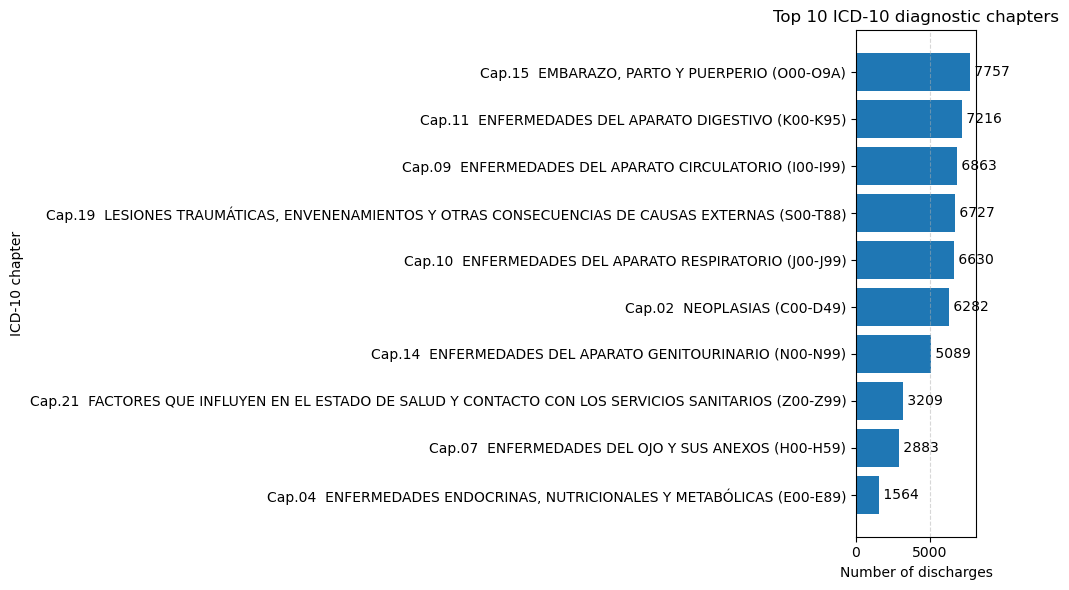

In [19]:
# B.1.1 Top diagnostic chapters

# Conteo por capítulo CIE-10
chapters_top10 = (
    grd_com["Capítulo"]
    .dropna()
    .value_counts()
    .head(10)
    .sort_values(ascending=True)
)

# Tabla
chapters_table = chapters_top10.reset_index()
chapters_table.columns = ["Capítulo", "discharges"]

print("Top 10 diagnostic chapters:")
display(chapters_table)

# Gráfico horizontal
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(chapters_top10.index, chapters_top10.values)

ax.set_title("Top 10 ICD-10 diagnostic chapters")
ax.set_xlabel("Number of discharges")
ax.set_ylabel("ICD-10 chapter")
ax.grid(axis="x", linestyle="--", alpha=0.5)

for i, v in enumerate(chapters_top10.values):
    ax.text(v, i, f" {v}", va="center")

plt.tight_layout()
plt.show()

Las hospitalizaciones en las comunas analizadas se concentran principalmente en embarazo, parto y puerperio, seguido por enfermedades del aparato digestivo, circulatorio y respiratorio. También destacan las lesiones traumáticas y otras consecuencias de causas externas, además de las neoplasias.

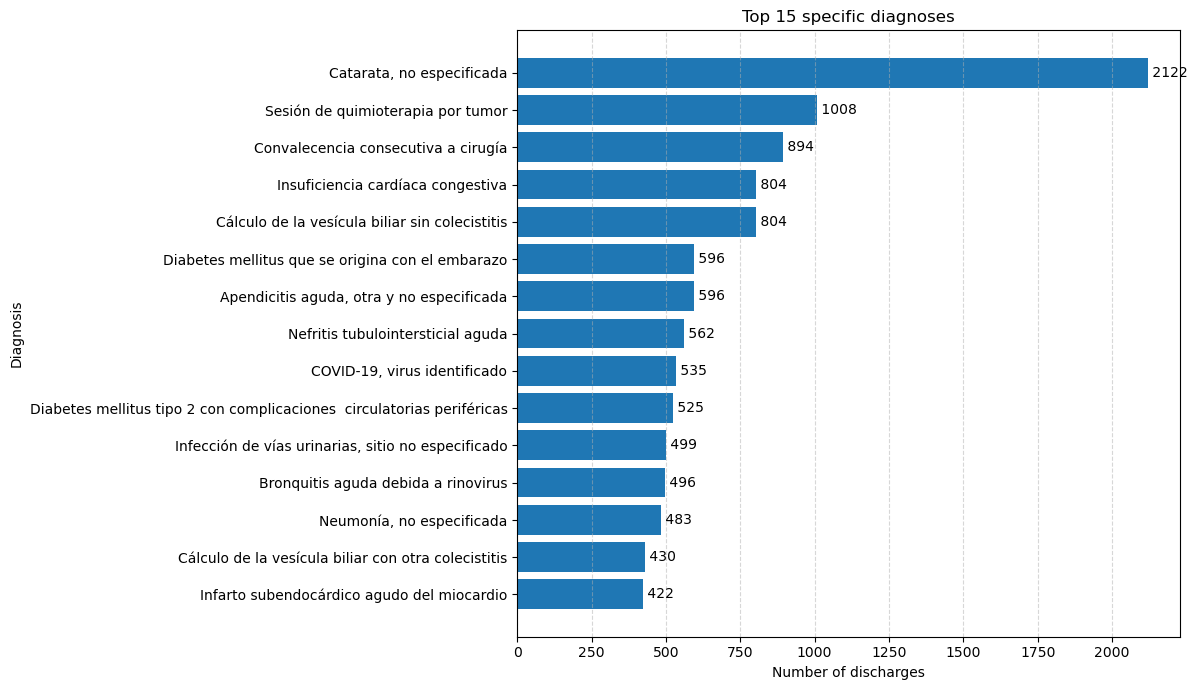

In [20]:
# B.1.2 Top specific diagnoses
# Top 15 diagnósticos específicos
diag_top15 = (
    grd_com["Descripción"]
    .dropna()
    .value_counts()
    .head(15)
    .sort_values(ascending=True)
)

labels = [d[:80] + "..." if len(d) > 80 else d for d in diag_top15.index]

fig, ax = plt.subplots(figsize=(12, 7))
ax.barh(labels, diag_top15.values)

ax.set_title("Top 15 specific diagnoses")
ax.set_xlabel("Number of discharges")
ax.set_ylabel("Diagnosis")
ax.grid(axis="x", linestyle="--", alpha=0.5)

for i, v in enumerate(diag_top15.values):
    ax.text(v, i, f" {v}", va="center")

plt.tight_layout()
plt.show()

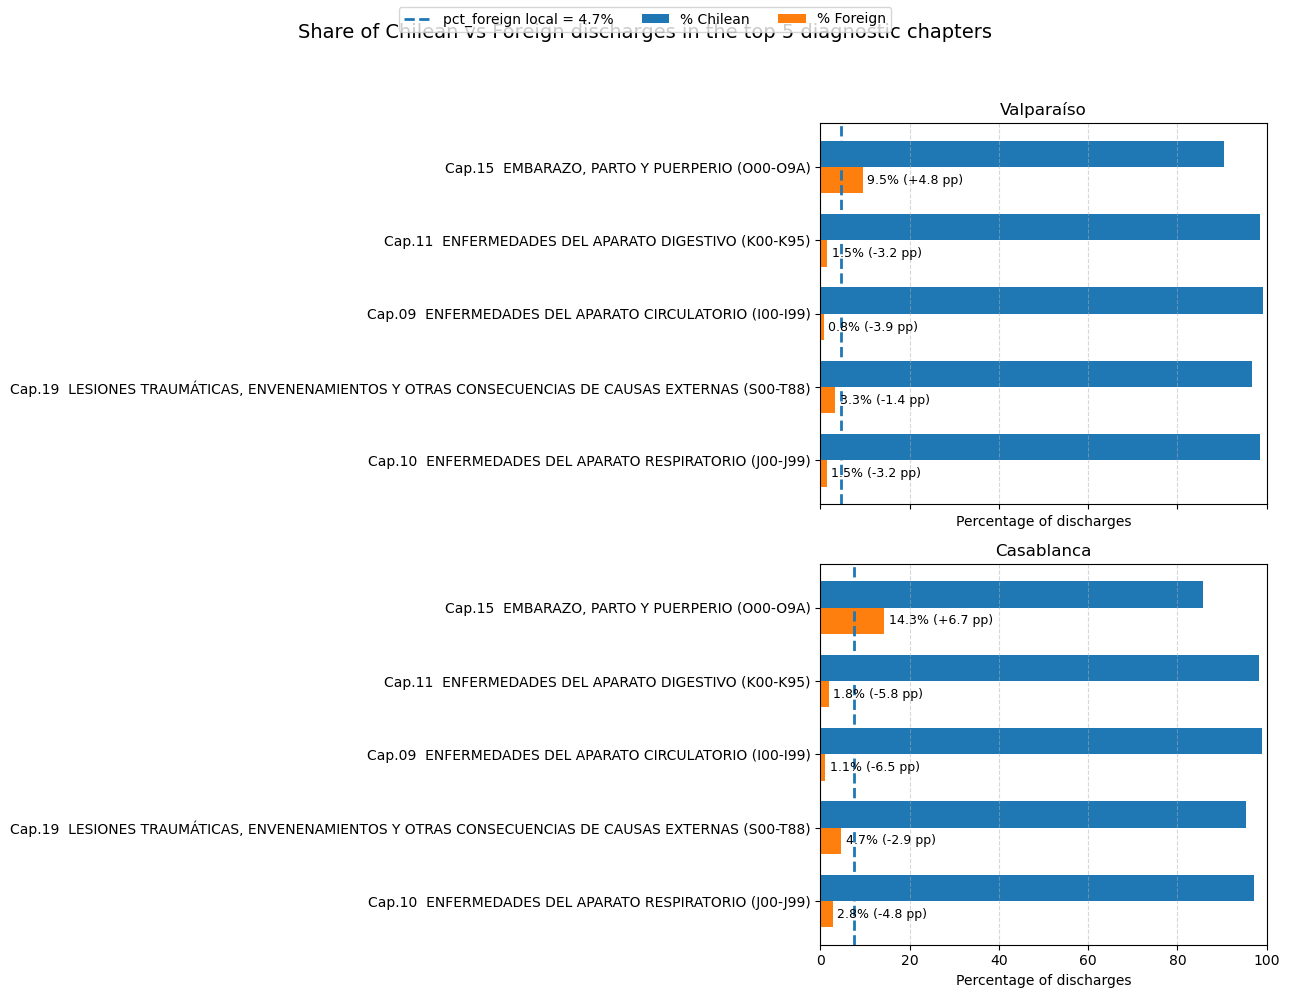

nat_group,COMUNA_NORM,Capítulo,Chilean,Foreign,% Chilean,% Foreign,pct_foreign_local,dif_pp,estado
1,Casablanca,Cap.10 ENFERMEDADES DEL APARATO RESPIRATORIO ...,445,13,97.16,2.84,7.6,-4.76,Sub-representado
4,Casablanca,"Cap.19 LESIONES TRAUMÁTICAS, ENVENENAMIENTOS ...",471,23,95.34,4.66,7.6,-2.94,Sub-representado
0,Casablanca,Cap.09 ENFERMEDADES DEL APARATO CIRCULATORIO ...,446,5,98.89,1.11,7.6,-6.49,Sub-representado
2,Casablanca,Cap.11 ENFERMEDADES DEL APARATO DIGESTIVO (K0...,537,10,98.17,1.83,7.6,-5.77,Sub-representado
3,Casablanca,"Cap.15 EMBARAZO, PARTO Y PUERPERIO (O00-O9A)",633,106,85.66,14.34,7.6,6.74,Sobre-representado
6,Valparaíso,Cap.10 ENFERMEDADES DEL APARATO RESPIRATORIO ...,6082,90,98.54,1.46,4.7,-3.24,Sub-representado
9,Valparaíso,"Cap.19 LESIONES TRAUMÁTICAS, ENVENENAMIENTOS ...",6026,207,96.68,3.32,4.7,-1.38,Sub-representado
5,Valparaíso,Cap.09 ENFERMEDADES DEL APARATO CIRCULATORIO ...,6359,53,99.17,0.83,4.7,-3.87,Sub-representado
7,Valparaíso,Cap.11 ENFERMEDADES DEL APARATO DIGESTIVO (K0...,6569,100,98.50,1.50,4.7,-3.20,Sub-representado
8,Valparaíso,"Cap.15 EMBARAZO, PARTO Y PUERPERIO (O00-O9A)",6351,667,90.50,9.50,4.7,4.80,Sobre-representado


In [21]:

# B.1.3 Diagnostic chapters by nationality
# Copia limpia
df = grd_com.copy()

# Asegurar comuna normalizada
if "COMUNA_NORM" not in df.columns:
    import unicodedata
    def normalize_text(x):
        if pd.isna(x):
            return pd.NA
        x = str(x).strip().upper()
        x = unicodedata.normalize("NFKD", x)
        x = "".join(c for c in x if not unicodedata.combining(c))
        x = " ".join(x.split())
        return x
    df["COMUNA_NORM"] = df["COMUNA"].apply(normalize_text)

# Benchmarks locales de Tarea 1
pct_foreign_map = {
    "VALPARAISO": 4.7,
    "CASABLANCA": 7.6
}

comuna_display = {
    "VALPARAISO": "Valparaíso",
    "CASABLANCA": "Casablanca"
}

# Top 5 capítulos diagnósticos en el total de tus comunas
top5_chapters = (
    df["Capítulo"]
    .dropna()
    .value_counts()
    .head(5)
    .index
    .tolist()
)

# Conteos por comuna, capítulo y nacionalidad
summary = (
    df[df["Capítulo"].isin(top5_chapters)]
    .groupby(["COMUNA_NORM", "Capítulo", "nat_group"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

# Asegurar columnas
for col in ["Chilean", "Foreign"]:
    if col not in summary.columns:
        summary[col] = 0

# Porcentajes
summary["total"] = summary["Chilean"] + summary["Foreign"]
summary = summary[summary["total"] > 0].copy()

summary["% Chilean"] = 100 * summary["Chilean"] / summary["total"]
summary["% Foreign"] = 100 * summary["Foreign"] / summary["total"]
summary["pct_foreign_local"] = summary["COMUNA_NORM"].map(pct_foreign_map)
summary["dif_pp"] = summary["% Foreign"] - summary["pct_foreign_local"]

summary["estado"] = np.where(
    summary["dif_pp"] > 0,
    "Sobre-representado",
    np.where(summary["dif_pp"] < 0, "Sub-representado", "Igual al benchmark")
)

# Ordenar capítulos según frecuencia total
summary["Capítulo"] = pd.Categorical(
    summary["Capítulo"],
    categories=top5_chapters[::-1],
    ordered=True
)

summary = summary.sort_values(["COMUNA_NORM", "Capítulo"])

# Gráfico: un panel por comuna
fig, axes = plt.subplots(2, 1, figsize=(13, 10), sharex=True)

bar_h = 0.36
comunas_plot = ["VALPARAISO", "CASABLANCA"]

for ax, comuna in zip(axes, comunas_plot):
    d = summary[summary["COMUNA_NORM"] == comuna].sort_values("Capítulo").copy()
    y = np.arange(len(d))
    pct_ref = pct_foreign_map[comuna]

    ax.barh(y + bar_h/2, d["% Chilean"], height=bar_h, label="% Chilean")
    ax.barh(y - bar_h/2, d["% Foreign"], height=bar_h, label="% Foreign")

    ax.axvline(
        pct_ref,
        linestyle="--",
        linewidth=2,
        label=f"pct_foreign local = {pct_ref}%"
    )

    for i, (_, row) in enumerate(d.iterrows()):
        signo = "+" if row["dif_pp"] >= 0 else ""
        ax.text(
            row["% Foreign"] + 1,
            y[i] - bar_h/2,
            f'{row["% Foreign"]:.1f}% ({signo}{row["dif_pp"]:.1f} pp)',
            va="center",
            fontsize=9
        )

    ax.set_yticks(y)
    ax.set_yticklabels(d["Capítulo"])
    ax.set_xlim(0, 100)
    ax.set_title(comuna_display[comuna])
    ax.set_xlabel("Percentage of discharges")
    ax.grid(axis="x", linestyle="--", alpha=0.5)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles[:3], labels[:3], loc="upper center", ncol=3)

fig.suptitle(
    "Share of Chilean vs Foreign discharges in the top 5 diagnostic chapters",
    y=0.98,
    fontsize=14
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# Tabla resumen
tabla_cap = summary[
    ["COMUNA_NORM", "Capítulo", "Chilean", "Foreign", "% Chilean", "% Foreign",
     "pct_foreign_local", "dif_pp", "estado"]
].copy()

tabla_cap["COMUNA_NORM"] = tabla_cap["COMUNA_NORM"].map(comuna_display)
display(tabla_cap.round(2))

En ambas comunas, la sobrerrepresentación de egresos en población extranjera se concentra claramente en el Capítulo XV: embarazo, parto y puerperio. En Valparaíso, este capítulo alcanza 9.5% de egresos extranjeros, superando el 4.7% de población extranjera local. En Casablanca, la diferencia es aún mayor: 14.3% frente a un 7.6% esperado según la composición poblacional.

En cambio, los demás capítulos principales —digestivo, circulatorio, respiratorio y lesiones/causas externas— muestran proporciones de egresos extranjeros por debajo del benchmark local en ambas comunas.

En síntesis, la única sobrerrepresentación clara y consistente corresponde a las hospitalizaciones obstétricas, mientras que el resto de los grandes grupos diagnósticos no presenta una participación extranjera superior a la esperada según la población local.

# B.2 Length of Stay & Severity

Mean and median LOS by nationality:


,nat_group,mean_los,median_los,n
0,Chilean,71.46,61.0,9880
1,Foreign,80.03,62.0,285


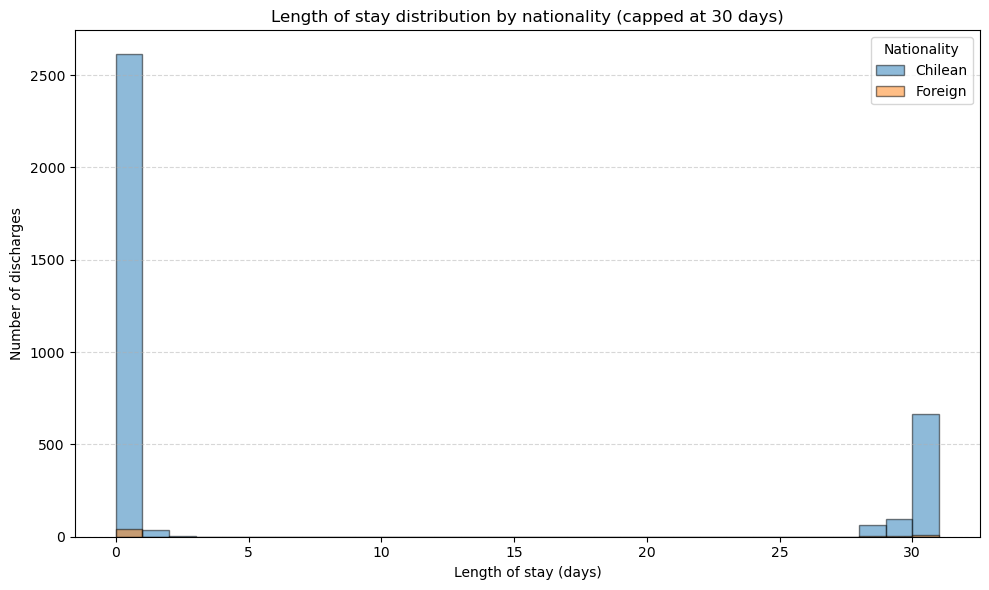

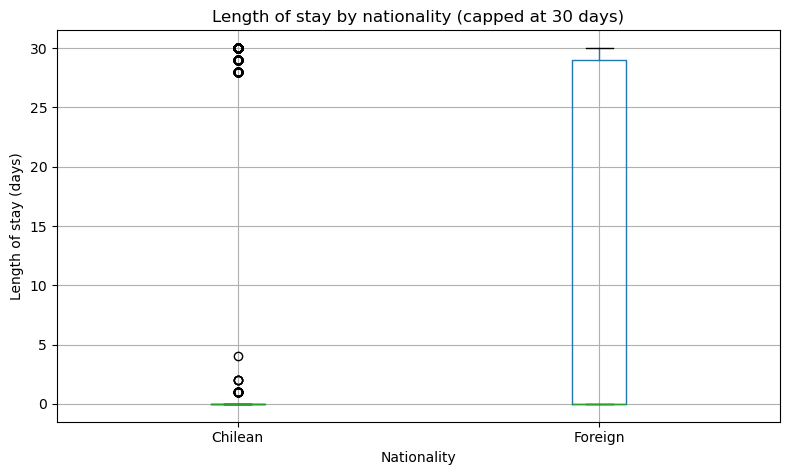

In [22]:
# B.2.1 Length of stay by nationality
# Trabajar solo con LOS válido y nat_group no nulo
df = grd_com.copy()
df = df[df["los"].notna() & df["nat_group"].notna()].copy()

# Tabla resumen: media y mediana por nacionalidad
los_summary = (
    df.groupby("nat_group")["los"]
    .agg(mean_los="mean", median_los="median", n="count")
    .reset_index()
)

print("Mean and median LOS by nationality:")
display(los_summary.round(2))

# Capar LOS en 30 días solo para visualización
df_plot = df[df["los"] <= 30].copy()

# Histograma superpuesto
fig, ax = plt.subplots(figsize=(10, 6))

for group in ["Chilean", "Foreign"]:
    vals = df_plot.loc[df_plot["nat_group"] == group, "los"]
    ax.hist(
        vals,
        bins=range(0, 32),
        alpha=0.5,
        label=group,
        edgecolor="black"
    )

ax.set_title("Length of stay distribution by nationality (capped at 30 days)")
ax.set_xlabel("Length of stay (days)")
ax.set_ylabel("Number of discharges")
ax.legend(title="Nationality")
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# Boxplot opcional
fig, ax = plt.subplots(figsize=(8, 5))
df_plot.boxplot(column="los", by="nat_group", ax=ax)

ax.set_title("Length of stay by nationality (capped at 30 days)")
ax.set_xlabel("Nationality")
ax.set_ylabel("Length of stay (days)")
plt.suptitle("")
plt.tight_layout()
plt.show()

La estadía hospitalaria presenta una distribución muy asimétrica en ambos grupos, con una alta concentración de egresos en estancias muy cortas. Visualmente, los pacientes extranjeros parecen mostrar una mayor dispersión y una presencia relativamente más marcada de estancias largas dentro del rango observado, mientras que en los pacientes chilenos la distribución se concentra más en valores bajos.

En términos generales, esto sugiere que podrían existir diferencias en la duración de la hospitalización por nacionalidad, pero no parecen ser completamente concluyentes solo a partir del gráfico. Dado el fuerte sesgo de la distribución y la acumulación de casos en valores extremos, conviene complementar la interpretación con la media y la mediana para evaluar si la diferencia es realmente relevante.

Columnas en Severidad GRD:
['Severidad', 'Unnamed: 1']
Severity distribution:


,IR_29301_SEVERIDAD,sev_label,nat_group,n
0,0,0,Chilean,8598
1,0,0,Foreign,138
2,1,1,Chilean,15456
3,1,1,Foreign,785
4,2,2,Chilean,20511
5,2,2,Foreign,604
6,3,3,Chilean,16476
7,3,3,Foreign,271


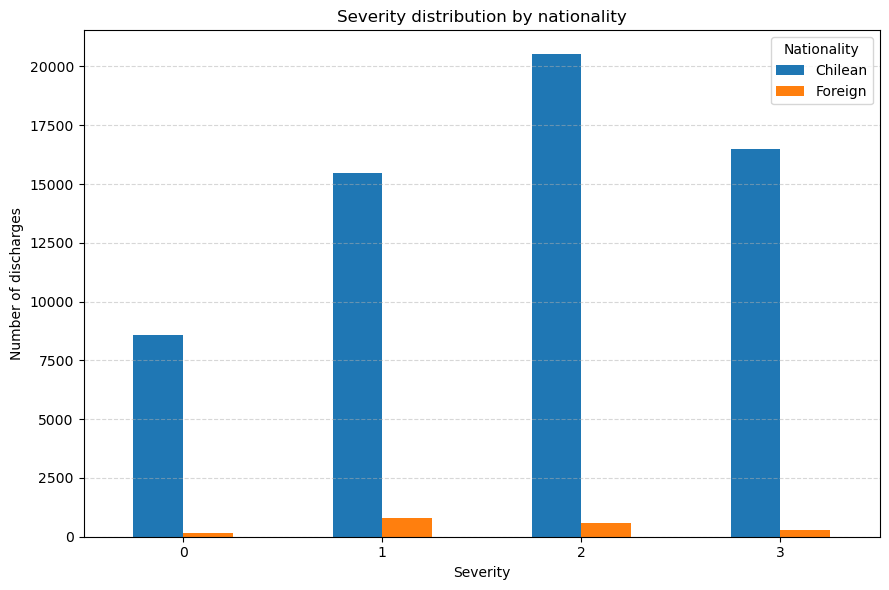

In [23]:
# B.2.2 Severity distribution
# Copia
df = grd_com.copy()

# Leer tabla maestra de severidad
sev_lookup = pd.read_excel(
    "grd/TablasMaestrasBasesGRD.xlsx",
    sheet_name="Severidad GRD"
).copy()

print("Columnas en Severidad GRD:")
print(sev_lookup.columns.tolist())

# Normalizar nombres de columnas por si vienen con variaciones
sev_lookup.columns = [str(c).strip() for c in sev_lookup.columns]

# Intenta detectar columnas de código y etiqueta
code_col = [c for c in sev_lookup.columns if "SEVER" in c.upper() or "COD" in c.upper() or "VALOR" in c.upper()][0]
label_col = [c for c in sev_lookup.columns if "DESC" in c.upper() or "GLOSA" in c.upper() or "ETIQU" in c.upper() or "SEVER" in c.upper()][-1]

sev_lookup = sev_lookup[[code_col, label_col]].drop_duplicates().copy()
sev_lookup.columns = ["sev_code", "sev_label"]

# Normalizar tipos
df["IR_29301_SEVERIDAD"] = pd.to_numeric(df["IR_29301_SEVERIDAD"], errors="coerce")
sev_lookup["sev_code"] = pd.to_numeric(sev_lookup["sev_code"], errors="coerce")

# Join para traer etiquetas
df = df.merge(sev_lookup, left_on="IR_29301_SEVERIDAD", right_on="sev_code", how="left")

# Fallback por si alguna etiqueta no aparece
fallback_map = {
    0: "No severity",
    1: "Minor",
    2: "Moderate",
    3: "Major"
}
df["sev_label"] = df["sev_label"].fillna(df["IR_29301_SEVERIDAD"].map(fallback_map))

# Quedarse solo con 0-3 válidos
df = df[df["IR_29301_SEVERIDAD"].isin([0, 1, 2, 3])].copy()

# Orden
severity_order = [0, 1, 2, 3]
label_order = (
    df.drop_duplicates("IR_29301_SEVERIDAD")
      .sort_values("IR_29301_SEVERIDAD")["sev_label"]
      .tolist()
)

# Tabla de distribución
sev_dist = (
    df.groupby(["IR_29301_SEVERIDAD", "sev_label", "nat_group"])
      .size()
      .reset_index(name="n")
      .sort_values(["IR_29301_SEVERIDAD", "nat_group"])
)

print("Severity distribution:")
display(sev_dist)

# Tabla ancha para gráfico
sev_plot = (
    df.groupby(["IR_29301_SEVERIDAD", "sev_label", "nat_group"])
      .size()
      .unstack(fill_value=0)
      .reset_index()
      .sort_values("IR_29301_SEVERIDAD")
)

sev_plot = sev_plot.set_index("sev_label")[["Chilean", "Foreign"]]

# Gráfico de barras agrupadas
ax = sev_plot.plot(kind="bar", figsize=(9, 6))

plt.title("Severity distribution by nationality")
plt.xlabel("Severity")
plt.ylabel("Number of discharges")
plt.xticks(rotation=0)
plt.legend(title="Nationality")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

La mayor parte de los egresos se concentra en niveles de severidad moderada (2) y mayor (3), tanto en pacientes chilenos como extranjeros. En ambos grupos, la categoría 2 es la más frecuente, seguida por las categorías 3 y 1, mientras que la categoría 0 es la menos común.

Visualmente, la distribución por severidad es bastante similar entre nacionalidades, sin diferencias marcadas en el perfil general. Esto sugiere que, al menos en términos descriptivos, la gravedad de los egresos hospitalarios no presenta contrastes importantes entre pacientes chilenos y extranjeros.

In [24]:
# B.2.3 Discharge type
df = grd_com.copy()

def normalize_text(x):
    if pd.isna(x):
        return pd.NA
    x = str(x).strip().upper()
    x = unicodedata.normalize("NFKD", x)
    x = "".join(c for c in x if not unicodedata.combining(c))
    x = " ".join(x.split())
    return x

# Normalizar TIPOALTA
df["TIPOALTA_NORM"] = df["TIPOALTA"].apply(normalize_text)

# Distribución de tipo de alta
tipoalta_dist = (
    df["TIPOALTA_NORM"]
    .value_counts(dropna=False)
    .rename_axis("TIPOALTA")
    .reset_index(name="n")
)

tipoalta_dist["pct"] = 100 * tipoalta_dist["n"] / tipoalta_dist["n"].sum()

print("Distribution of discharge outcomes:")
display(tipoalta_dist)

# Mortalidad intrahospitalaria por nacionalidad
mort_table = (
    df.groupby("nat_group")
    .agg(
        total_discharges=("TIPOALTA_NORM", "size"),
        deaths=("TIPOALTA_NORM", lambda s: (s == "FALLECIDO").sum())
    )
    .reset_index()
)

mort_table["in_hospital_mortality_rate_pct"] = (
    100 * mort_table["deaths"] / mort_table["total_discharges"]
)

print("In-hospital mortality rate by nationality:")
display(mort_table.round(2))

Distribution of discharge outcomes:


,TIPOALTA,n,pct
0,DOMICILIO,51562,82.054138
1,HOSPITALIZACION DOMICILIARIA,3705,5.896020
2,DERIVACION OTRO HOSPITAL DEL SERVICIO,2968,4.723181
3,FALLECIDO,2165,3.445313
4,"DERIVACION A OTROS CENTROS (CARCEL, HOGAR DE",648,1.031207
5,DERIVACION OTRO HOSPITAL DE LA RED NACIONAL,587,0.934133
6,ALTA VOLUNTARIA,478,0.760674
7,DERIVACION INST. PRIVADA (COMPRA DE SERVICIOS,359,0.571301
8,FUGA DEL PACIENTE,304,0.483776
9,DERIVACION INST. PRIVADA (VOLUNTARIO),63,0.100256


In-hospital mortality rate by nationality:


,nat_group,total_discharges,deaths,in_hospital_mortality_rate_pct
0,Chilean,61041,2150,3.52
1,Foreign,1798,15,0.83


# B.3 Spatial View

Tabla de tasas:


,codigo_comuna,nombre_comuna,pop_total,total_discharges,hosp_rate_per_10k
0,05101,Valparaíso,284938,58162,2041.215984
1,05102,Casablanca,29876,4677,1565.470612



Comunas encontradas en shapefile:


,CUT_COM,COMUNA,nombre_comuna,hosp_rate_per_10k
0,05101,Valparaíso,Valparaíso,2041.215984
1,05102,Casablanca,Casablanca,1565.470612


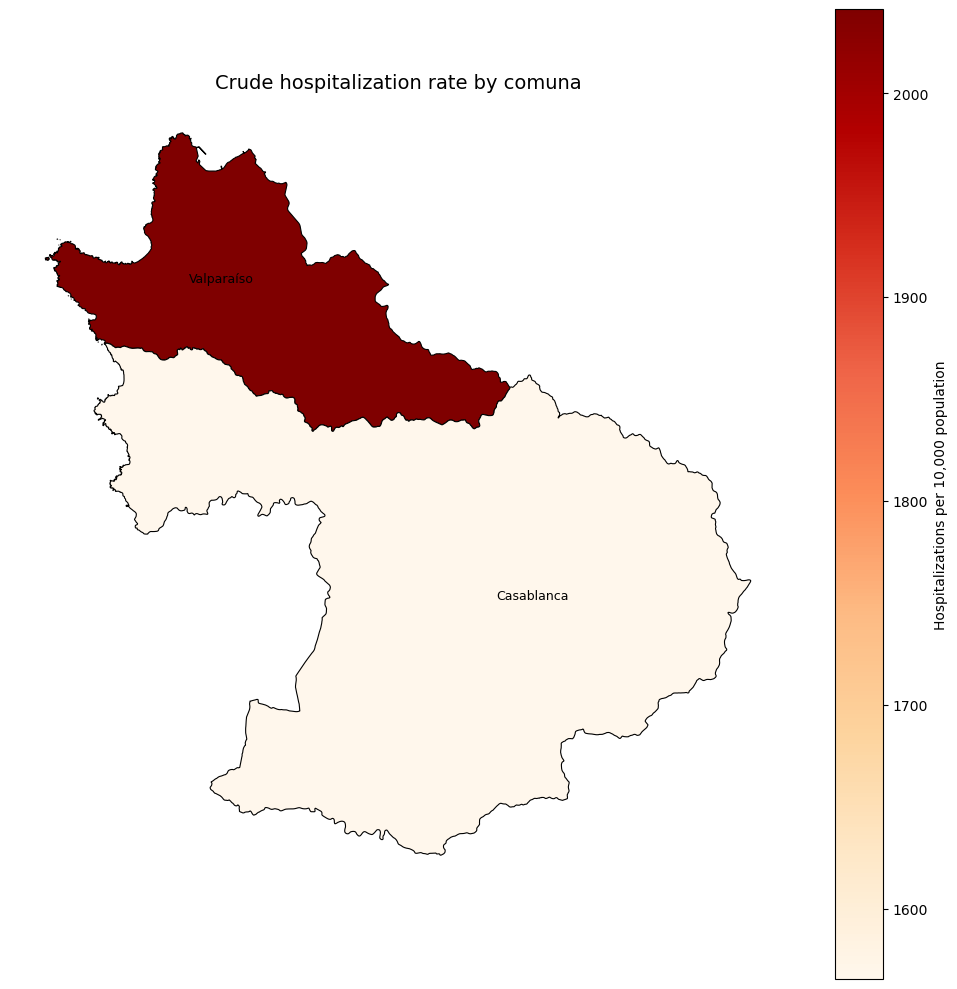

In [25]:
# B.3.1 Choropleth: hospitalization rate by comuna
# -----------------------------------
# 1) Tabla base de comunas + población
# -----------------------------------
# Reemplaza pop_total por tus valores reales de Tarea 1
comuna_info = pd.DataFrame({
    "codigo_comuna": ["05101", "05102"],
    "nombre_comuna": ["Valparaíso", "Casablanca"],
    "pop_total": [284938, 29876] 
})

# -----------------------------------
# 2) Resumen GRD por comuna
# -----------------------------------
df = grd_com.copy()

# Normalizar nombres para mapear a código
name_to_code = {
    "VALPARAISO": "05101",
    "CASABLANCA": "05102"
}

import unicodedata
def normalize_text(x):
    if pd.isna(x):
        return pd.NA
    x = str(x).strip().upper()
    x = unicodedata.normalize("NFKD", x)
    x = "".join(c for c in x if not unicodedata.combining(c))
    x = " ".join(x.split())
    return x

df["COMUNA_NORM"] = df["COMUNA"].apply(normalize_text)
df["codigo_comuna"] = df["COMUNA_NORM"].map(name_to_code)

grd_summary = (
    df.groupby("codigo_comuna")
      .size()
      .reset_index(name="total_discharges")
)

grd_summary = comuna_info.merge(grd_summary, on="codigo_comuna", how="left")
grd_summary["total_discharges"] = grd_summary["total_discharges"].fillna(0).astype(int)
grd_summary["hosp_rate_per_10k"] = (
    grd_summary["total_discharges"] / grd_summary["pop_total"] * 10000
)

print("Tabla de tasas:")
display(grd_summary)

# -----------------------------------
# 3) Leer shapefile y hacer merge
# -----------------------------------
comunas_gdf = gpd.read_file("COMUNAS/comunas.shp").copy()

# Asegurar formato del código
comunas_gdf["CUT_COM"] = comunas_gdf["CUT_COM"].astype(str).str.zfill(5)

# Filtrar solo tus comunas
map_gdf = comunas_gdf.merge(
    grd_summary,
    left_on="CUT_COM",
    right_on="codigo_comuna",
    how="inner"
)

print("\nComunas encontradas en shapefile:")
display(map_gdf[["CUT_COM", "COMUNA", "nombre_comuna", "hosp_rate_per_10k"]])

# -----------------------------------
# 4) Mapa coroplético
# -----------------------------------
fig, ax = plt.subplots(figsize=(10, 10))

map_gdf.plot(
    column="hosp_rate_per_10k",
    cmap="OrRd",
    linewidth=0.8,
    edgecolor="black",
    legend=True,
    ax=ax,
    legend_kwds={"label": "Hospitalizations per 10,000 population"}
)

# Etiquetas
for _, row in map_gdf.iterrows():
    pt = row.geometry.representative_point()
    ax.annotate(
        text=row["nombre_comuna"],
        xy=(pt.x, pt.y),
        ha="center",
        fontsize=9
    )

ax.set_title("Crude hospitalization rate by comuna", fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.show()

# B.4 Comuna-Level GRD Summary Table

In [26]:
# -----------------------------------
# 1) Datos base de Tarea 1
# -----------------------------------
# Reemplaza pop_total por tus valores reales
comuna_info = pd.DataFrame({
    "codigo_comuna": ["05101", "05102"],
    "nombre_comuna": ["Valparaíso", "Casablanca"],
    "pop_total": [None, None]   # <-- reemplazar con Tarea 1
})


# -----------------------------------
# 2) Función auxiliar
# -----------------------------------
def normalize_text(x):
    if pd.isna(x):
        return pd.NA
    x = str(x).strip().upper()
    x = unicodedata.normalize("NFKD", x)
    x = "".join(c for c in x if not unicodedata.combining(c))
    x = " ".join(x.split())
    return x

# -----------------------------------
# 3) Preparar base GRD
# -----------------------------------
df = grd_com.copy()

# Normalizar comuna y mapear a código
df["COMUNA_NORM"] = df["COMUNA"].apply(normalize_text)

name_to_code = {
    "VALPARAISO": "05101",
    "CASABLANCA": "05102"
}
code_to_name = {
    "05101": "Valparaíso",
    "05102": "Casablanca"
}

df["codigo_comuna"] = df["COMUNA_NORM"].map(name_to_code)
df["nombre_comuna"] = df["codigo_comuna"].map(code_to_name)

# Normalizar TIPOALTA si no existe TIPOALTA_NORM
if "TIPOALTA_NORM" not in df.columns:
    df["TIPOALTA_NORM"] = df["TIPOALTA"].apply(normalize_text)

# Asegurar severity numérica
df["IR_29301_SEVERIDAD"] = pd.to_numeric(df["IR_29301_SEVERIDAD"], errors="coerce")

# -----------------------------------
# 4) Función resumen por comuna
# -----------------------------------
def build_grd_summary(g):
    grd_total = len(g)
    grd_chilean = (g["nat_group"] == "Chilean").sum()
    grd_foreign = (g["nat_group"] == "Foreign").sum()

    grd_pct_foreign = 100 * grd_foreign / grd_total if grd_total > 0 else pd.NA

    grd_mean_los = g["los"].mean()
    grd_mean_los_chilean = g.loc[g["nat_group"] == "Chilean", "los"].mean()
    grd_mean_los_foreign = g.loc[g["nat_group"] == "Foreign", "los"].mean()

    grd_mean_severity = g["IR_29301_SEVERIDAD"].mean()

    grd_mortality_rate = 100 * (g["TIPOALTA_NORM"] == "FALLECIDO").mean()

    top3_chapters = (
        g["Capítulo"]
        .dropna()
        .value_counts()
        .head(3)
        .index
        .tolist()
    )

    return pd.Series({
        "grd_total": grd_total,
        "grd_chilean": int(grd_chilean),
        "grd_foreign": int(grd_foreign),
        "grd_pct_foreign": grd_pct_foreign,
        "grd_mean_los": grd_mean_los,
        "grd_mean_los_chilean": grd_mean_los_chilean,
        "grd_mean_los_foreign": grd_mean_los_foreign,
        "grd_mean_severity": grd_mean_severity,
        "grd_mortality_rate": grd_mortality_rate,
        "grd_top3_chapters": ", ".join(top3_chapters)
    })

# -----------------------------------
# 5) Construir tabla resumen
# -----------------------------------
grd_summary = (
    df.groupby("codigo_comuna")
      .apply(build_grd_summary)
      .reset_index()
)

# Unir con nombre y población
grd_summary = comuna_info.merge(grd_summary, on="codigo_comuna", how="left")

# Calcular tasa por 10.000
grd_summary["grd_rate_per_10k"] = (
    grd_summary["grd_total"] / grd_summary["pop_total"] * 10000
)

# Orden final de columnas
grd_summary = grd_summary[
    [
        "codigo_comuna",
        "nombre_comuna",
        "grd_total",
        "grd_chilean",
        "grd_foreign",
        "grd_pct_foreign",
        "grd_mean_los",
        "grd_mean_los_chilean",
        "grd_mean_los_foreign",
        "grd_mean_severity",
        "grd_mortality_rate",
        "grd_top3_chapters",
        "grd_rate_per_10k"
    ]
].sort_values("codigo_comuna")

# Redondear columnas numéricas para mostrar
cols_round = [
    "grd_pct_foreign",
    "grd_mean_los",
    "grd_mean_los_chilean",
    "grd_mean_los_foreign",
    "grd_mean_severity",
    "grd_mortality_rate",
    "grd_rate_per_10k"
]
grd_summary[cols_round] = grd_summary[cols_round].round(2)

# -----------------------------------
# 6) Mostrar y guardar
# -----------------------------------
display(grd_summary)

os.makedirs("output", exist_ok=True)
grd_summary.to_csv("output/tarea2_grd_summary.csv", index=False, encoding="utf-8-sig")

print("Archivo guardado en: output/tarea2_grd_summary.csv")

,codigo_comuna,nombre_comuna,grd_total,grd_chilean,grd_foreign,grd_pct_foreign,grd_mean_los,grd_mean_los_chilean,grd_mean_los_foreign,grd_mean_severity,grd_mortality_rate,grd_top3_chapters,grd_rate_per_10k
0,05101,Valparaíso,58162,56573,1589,2.73,72.01,71.79,79.90,1.73,3.51,"Cap.15 EMBARAZO, PARTO Y PUERPERIO (O00-O9A),...",NaN
1,05102,Casablanca,4677,4468,209,4.47,67.97,67.35,80.97,1.69,2.65,"Cap.15 EMBARAZO, PARTO Y PUERPERIO (O00-O9A),...",NaN


Archivo guardado en: output/tarea2_grd_summary.csv
